Abon, Benedict Aldous A.<br>
CPE311 - CPE22S3<br>
03/29/26<br>
03/29/26<br>
Engr. Neil Barton James Matira<br>

# Seatwork 10.1 Case Study: Improving RT-IoT2022 Analysis

### Guide Questions
- What is the distribution of the Attack_type classes (normal vs. various attacks), and what percentage of the 123,117 instances does each class comprise?

- How do the categorical features proto (protocol) and service vary across different attack types and normal traffic patterns? Links to an external site.

- What are the mean and standard deviation of flow_duration for each Attack_type, and are differences statistically significant?

- Which continuous features (e.g., fwd_pkts_per_sec, bwd_pkts_per_sec, payload_bytes_per_second) exhibit the highest correlation with specific attack classes?

- How do time‑based features like fwd_iat.avg and bwd_iat.avg (mean inter‑arrival times) differ between various attack types and normal traffic?

- Which network flag counts (e.g., flow_SYN_flag_count, flow_RST_flag_count, fwd_PSH_flag_count) are most indicative of specific intrusion patterns?

# Extract

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("RT_IOT2022.csv")
df.head()

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240.0,26847.0,502.0,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240.0,26847.0,502.0,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240.0,26847.0,502.0,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240.0,26847.0,502.0,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240.0,26847.0,502.0,MQTT_Publish


In [5]:
print(f"df shape: {df.shape}")

df shape: (71726, 85)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71726 entries, 0 to 71725
Data columns (total 85 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no                        71726 non-null  int64  
 1   id.orig_p                 71726 non-null  int64  
 2   id.resp_p                 71726 non-null  int64  
 3   proto                     71726 non-null  object 
 4   service                   71726 non-null  object 
 5   flow_duration             71726 non-null  float64
 6   fwd_pkts_tot              71726 non-null  int64  
 7   bwd_pkts_tot              71726 non-null  int64  
 8   fwd_data_pkts_tot         71726 non-null  int64  
 9   bwd_data_pkts_tot         71726 non-null  int64  
 10  fwd_pkts_per_sec          71726 non-null  float64
 11  bwd_pkts_per_sec          71726 non-null  float64
 12  flow_pkts_per_sec         71726 non-null  float64
 13  down_up_ratio             71726 non-null  float64
 14  fwd_he

In [7]:
df.describe()

,no,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,71726.000000,71726.000000,71726.000000,71726.000000,71726.000000,71726.000000,71726.000000,71726.000000,7.172600e+04,7.172600e+04,...,7.172500e+04,7.172500e+04,7.172500e+04,7.172500e+04,7.172500e+04,7.172500e+04,7.172500e+04,71725.000000,71725.000000,71725.000000
mean,19084.036082,33574.049327,360.095419,6.510848,3.133187,2.675919,1.870493,1.405278,3.009638e+05,3.009288e+05,...,2.427388e+05,3.121508e+04,2.774092e+06,2.920035e+06,6.035806e+06,2.856809e+06,7.786186e+04,9353.673698,4670.187578,297.753963
std,15964.751569,15839.614886,1682.857311,170.209742,28.849043,43.240765,25.281068,42.300125,3.512237e+05,3.512460e+05,...,7.376857e+05,3.670540e+05,1.140152e+07,1.197353e+07,1.610379e+08,1.165504e+07,1.428293e+06,22587.988577,12698.292171,3410.567650
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,4332.250000,20442.250000,21.000000,0.000001,1.000000,1.000000,1.000000,0.000000,1.885463e+01,1.785649e+01,...,1.192093e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
50%,15071.500000,35942.000000,21.000000,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,2.467238e+05,...,4.053116e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
75%,33002.750000,46464.000000,53.000000,0.000152,1.000000,1.000000,1.000000,0.000000,2.621440e+05,2.621440e+05,...,1.499653e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
max,50934.000000,65446.000000,50003.000000,21728.335578,4345.000000,10112.000000,4345.000000,10105.000000,1.048576e+06,1.048576e+06,...,2.180349e+07,3.078395e+07,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000000,65535.000000,65535.000000


# Transform

In [8]:
# create df copy
iot_22_df = df.copy()

### 1. Attack type distribution

In [9]:
attack_type_distribution = pd.DataFrame(iot_22_df['Attack_type'].value_counts())
attack_type_distribution

,count
Attack_type,
DOS_SYN_Hping,50934
Thing_Speak,8108
ARP_poisioning,7750
MQTT_Publish,4146
DDOS_Slowloris,534
Wipro_bulb,253


In [10]:
# Attack_type percentage
attack_type_sum = attack_type_distribution['count'].sum()

# percentage computation, round off 2 decimal places
attack_type_distribution['percentage'] = (attack_type_distribution['count'] / attack_type_sum) * 100
attack_type_distribution['percentage'] = attack_type_distribution['percentage'].round(2)

attack_type_distribution

,count,percentage
Attack_type,,
DOS_SYN_Hping,50934,71.01
Thing_Speak,8108,11.30
ARP_poisioning,7750,10.81
MQTT_Publish,4146,5.78
DDOS_Slowloris,534,0.74
Wipro_bulb,253,0.35


### 2. Protocol vs Attack type, Service vs Attack type

In [11]:
# service column: Change category '-' with 'None'
iot_22_df['service'] = iot_22_df['service'].astype('category')
iot_22_df['service'] = iot_22_df['service'].cat.rename_categories({'-':'None'})
iot_22_df['service']

,service
0,mqtt
1,mqtt
2,mqtt
3,mqtt
4,mqtt
...,...
71721,None
71722,None
71723,None
71724,None


In [12]:
# protocol by attack type
proto_by_attack_type = iot_22_df.groupby('Attack_type')['proto'].value_counts().unstack().fillna(0)
proto_by_attack_type

proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,8.0,1927.0,5815.0
DDOS_Slowloris,0.0,529.0,5.0
DOS_SYN_Hping,0.0,50934.0,0.0
MQTT_Publish,0.0,4146.0,0.0
Thing_Speak,45.0,3779.0,4284.0
Wipro_bulb,2.0,182.0,69.0


In [13]:

# service by attack type
service_by_attack_type = iot_22_df.groupby('Attack_type')['service'].value_counts().unstack().fillna(0)
service_by_attack_type

service,None,dhcp,dns,http,irc,mqtt,ntp,ssl
Attack_type,,,,,,,,
ARP_poisioning,546,26,5583,129,0,0,7,1459
DDOS_Slowloris,6,2,3,523,0,0,0,0
DOS_SYN_Hping,50934,0,0,0,0,0,0,0
MQTT_Publish,11,0,0,3,0,4132,0,0
Thing_Speak,151,14,4069,2667,0,0,110,1097
Wipro_bulb,45,5,53,0,43,0,0,107


3. Flow duration stats per Attack type

In [14]:
# flow stats by atk type
flow_stats_by_atk = iot_22_df.groupby('Attack_type').agg({
    'flow_duration': ['mean', 'std']
})

flow_stats_by_atk

flow_duration             
                        mean          std
Attack_type                              
ARP_poisioning     15.893538   108.261070
DDOS_Slowloris     14.699148    14.124797
DOS_SYN_Hping       0.000003     0.000002
MQTT_Publish       43.397013    24.341563
Thing_Speak         0.934471     5.251602
Wipro_bulb        586.845727  2738.891637

4. Packets per second and bytes per second vs Attack type

In [15]:
# correlation of attack classes to fwd_pkts_per_sec, bwd_pkts_per_sec, payload_bytes_per_second
atk_classes_rate_corr = iot_22_df.groupby('Attack_type')[['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'payload_bytes_per_second']].corr().unstack().fillna(0)

atk_classes_rate_corr

fwd_pkts_per_sec                                            \
               fwd_pkts_per_sec bwd_pkts_per_sec payload_bytes_per_second   
Attack_type                                                                 
ARP_poisioning              1.0         0.481295                 0.428880   
DDOS_Slowloris              1.0        -0.184847                 0.999066   
DOS_SYN_Hping               1.0         1.000000                 1.000000   
MQTT_Publish                1.0         0.982272                 0.036978   
Thing_Speak                 1.0         0.721518                 0.775788   
Wipro_bulb                  1.0        -0.010643                 0.845673   

               bwd_pkts_per_sec                                            \
               fwd_pkts_per_sec bwd_pkts_per_sec payload_bytes_per_second   
Attack_type                                                                 
ARP_poisioning         0.481295              1.0                 0.893118   
DDOS_Slowloris        -0.184847              1.0                -0.142209   
DOS_SYN_Hping          1.000000              1.0                 1.000000   
MQTT_Publish           0.982272              1.0                 0.222918   
Thing_Speak            0.721518              1.0                 0.721317   
Wipro_bulb            -0.010643              1.0                 0.520243   

               payload_bytes_per_second                   \
                       fwd_pkts_per_sec bwd_pkts_per_sec   
Attack_type                                                
ARP_poisioning                 0.428880         0.893118   
DDOS_Slowloris                 0.999066        -0.142209   
DOS_SYN_Hping                  1.000000         1.000000   
MQTT_Publish                   0.036978         0.222918   
Thing_Speak                    0.775788         0.721317   
Wipro_bulb                     0.845673         0.520243   

                                         
               payload_bytes_per_second  
Attack_type                              
ARP_poisioning                      1.0  
DDOS_Slowloris                      1.0  
DOS_SYN_Hping                       1.0  
MQTT_Publish                        1.0  
Thing_Speak                         1.0  
Wipro_bulb                          1.0

5. Time-based features vs Attack types

In [42]:
time_features_atk_corr = iot_22_df.groupby('Attack_type')[['fwd_iat.avg', 'bwd_iat.avg']].corr().fillna(0)

time_features_atk_corr

fwd_iat.avg  bwd_iat.avg
Attack_type                                         
ARP_poisioning fwd_iat.avg     1.000000     0.840953
               bwd_iat.avg     0.840953     1.000000
DOS_SYN_Hping  fwd_iat.avg     0.000000     0.000000
               bwd_iat.avg     0.000000     0.000000
MQTT_Publish   fwd_iat.avg     1.000000     0.555960
               bwd_iat.avg     0.555960     1.000000
Others         fwd_iat.avg     1.000000     0.614811
               bwd_iat.avg     0.614811     1.000000
Thing_Speak    fwd_iat.avg     1.000000     0.077886
               bwd_iat.avg     0.077886     1.000000

6. Network flag counts per Attack type

In [17]:
# network flag counts on intrusion patterns
atk_classes_flag_counts = iot_22_df.groupby('Attack_type').agg({
    'flow_SYN_flag_count':'count',
    'flow_RST_flag_count':'count',
    'fwd_PSH_flag_count':'count'
})

atk_classes_flag_counts

,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count
Attack_type,,,
ARP_poisioning,7750,7750,7750
DDOS_Slowloris,534,534,534
DOS_SYN_Hping,50934,50934,50934
MQTT_Publish,4146,4146,4146
Thing_Speak,8108,8108,8108
Wipro_bulb,253,253,253


# Load

### 1. What is the distribution of the Attack_type classes (normal vs. various attacks), and what percentage of the 123,117 instances does each class comprise?

In [18]:
attack_type_distribution

,count,percentage
Attack_type,,
DOS_SYN_Hping,50934,71.01
Thing_Speak,8108,11.30
ARP_poisioning,7750,10.81
MQTT_Publish,4146,5.78
DDOS_Slowloris,534,0.74
Wipro_bulb,253,0.35


In [19]:
# Attack types below 1%
low_percentage_attacks = attack_type_distribution[attack_type_distribution['percentage'] < 1].index
iot_22_df['Attack_type'] = iot_22_df['Attack_type'].replace(low_percentage_attacks, 'Others')

# Crate new df with others category
attack_type_distribution = pd.DataFrame(iot_22_df['Attack_type'].value_counts())

# recalculate percentages
attack_type_sum = attack_type_distribution['count'].sum()
attack_type_distribution['percentage'] = (attack_type_distribution['count'] / attack_type_sum) * 100
attack_type_distribution['percentage'] = attack_type_distribution['percentage'].round(2)

attack_type_distribution

,count,percentage
Attack_type,,
DOS_SYN_Hping,50934,71.01
Thing_Speak,8108,11.30
ARP_poisioning,7750,10.81
MQTT_Publish,4146,5.78
Others,787,1.10


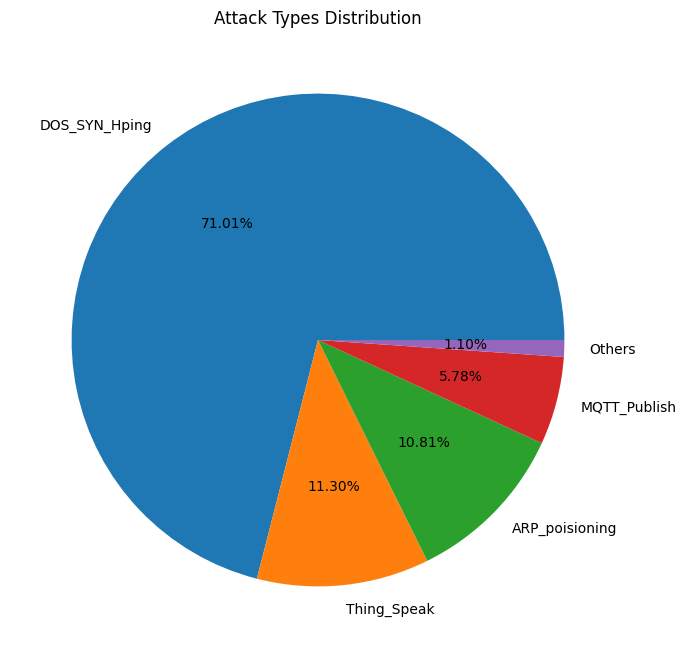

In [20]:
labels = attack_type_distribution.index

fig, ax = plt.subplots(figsize=(10,8))
ax.pie(attack_type_distribution['percentage'], labels=labels, autopct='%1.2f%%', labeldistance=1.1)
plt.title("Attack Types Distribution")

plt.show()

### 2. How do the categorical features proto (protocol) and service vary across different attack types and normal traffic patterns?

In [21]:
proto_by_attack_type

proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,8.0,1927.0,5815.0
DDOS_Slowloris,0.0,529.0,5.0
DOS_SYN_Hping,0.0,50934.0,0.0
MQTT_Publish,0.0,4146.0,0.0
Thing_Speak,45.0,3779.0,4284.0
Wipro_bulb,2.0,182.0,69.0


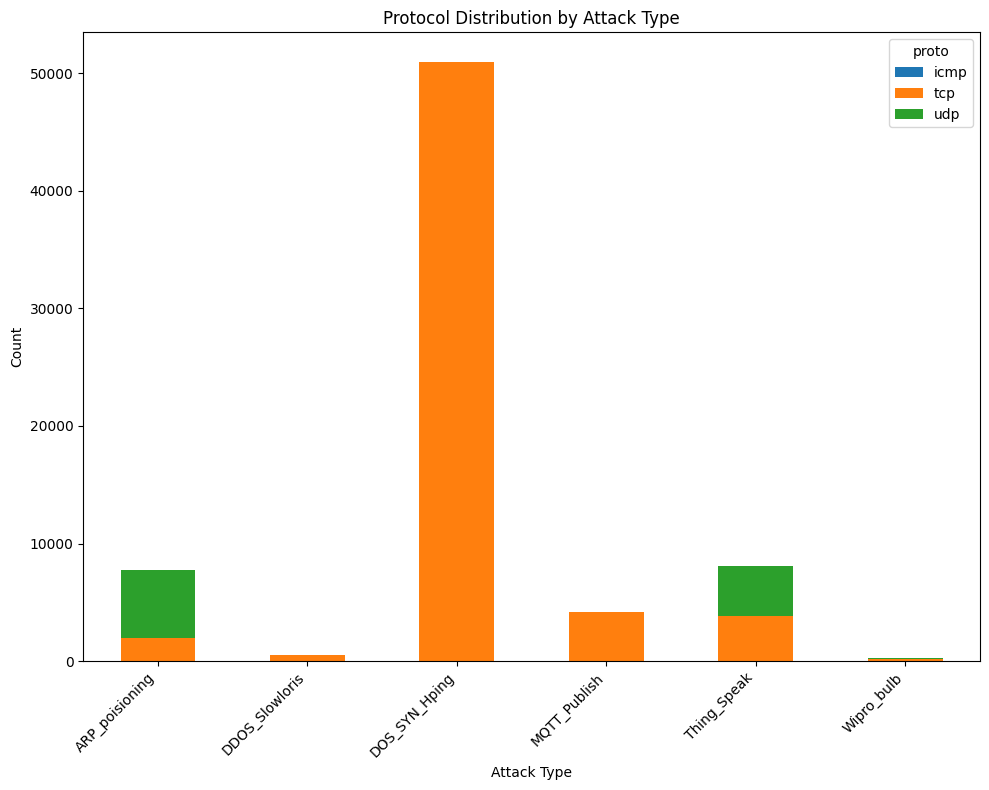

In [22]:
# Protocol by Attack type Visualization
plt.figure(figsize=(10,8))
proto_by_attack_type.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Protocol Distribution by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [23]:
service_by_attack_type

service,None,dhcp,dns,http,irc,mqtt,ntp,ssl
Attack_type,,,,,,,,
ARP_poisioning,546,26,5583,129,0,0,7,1459
DDOS_Slowloris,6,2,3,523,0,0,0,0
DOS_SYN_Hping,50934,0,0,0,0,0,0,0
MQTT_Publish,11,0,0,3,0,4132,0,0
Thing_Speak,151,14,4069,2667,0,0,110,1097
Wipro_bulb,45,5,53,0,43,0,0,107


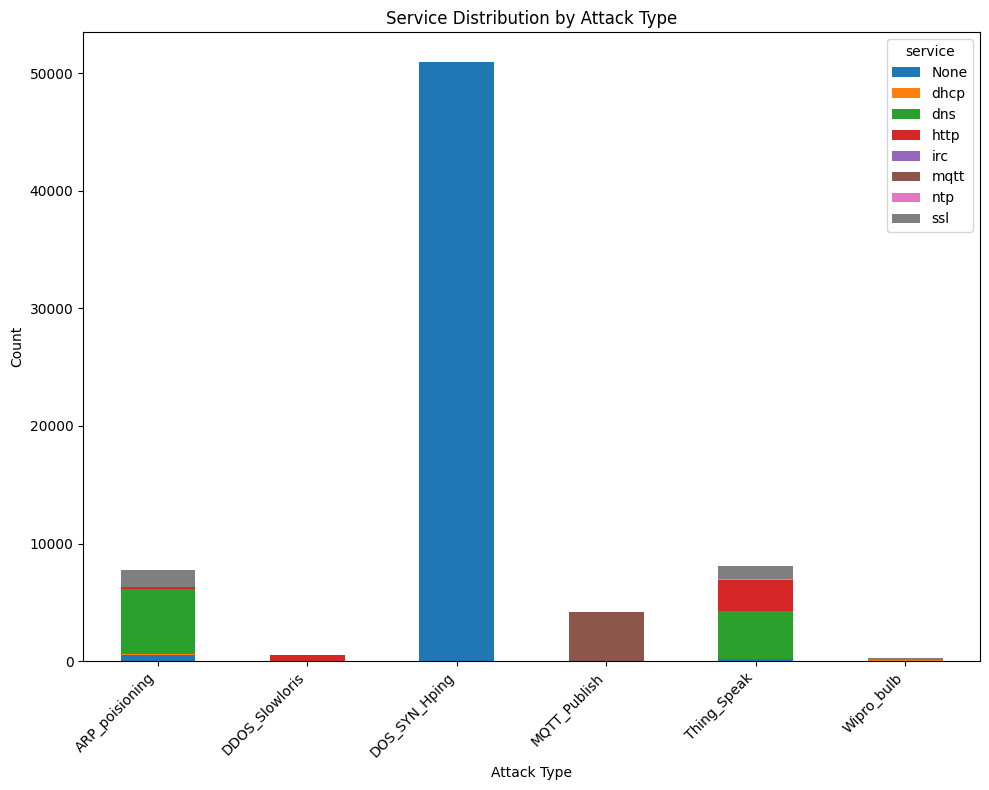

In [24]:
# Service by Attack type Visualization
plt.figure(figsize=(10,8))
service_by_attack_type.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Service Distribution by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 3. What are the mean and standard deviation of flow_duration for each Attack_type, and are differences statistically significant?

In [25]:
flow_stats_by_atk

flow_duration             
                        mean          std
Attack_type                              
ARP_poisioning     15.893538   108.261070
DDOS_Slowloris     14.699148    14.124797
DOS_SYN_Hping       0.000003     0.000002
MQTT_Publish       43.397013    24.341563
Thing_Speak         0.934471     5.251602
Wipro_bulb        586.845727  2738.891637

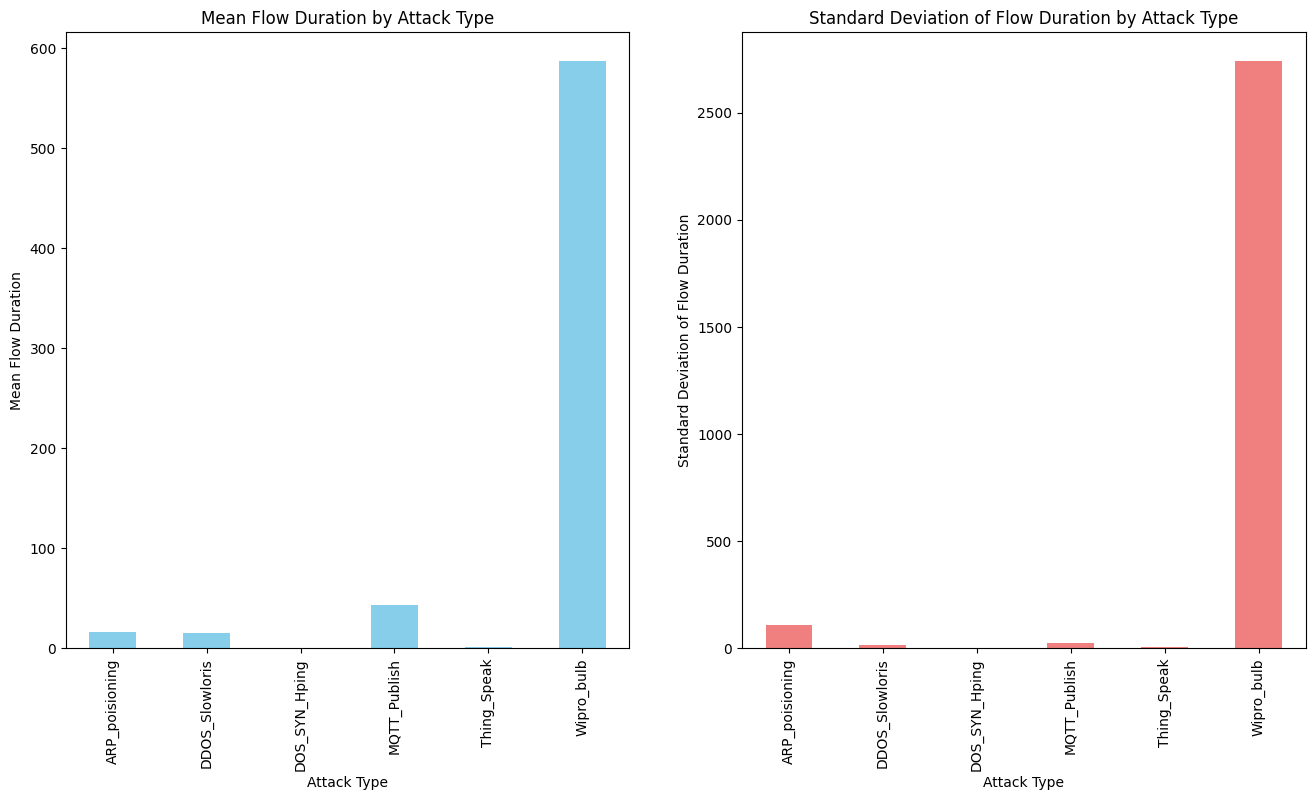

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# mean flow duration
flow_stats_by_atk['flow_duration']['mean'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Mean Flow Duration by Attack Type')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Mean Flow Duration')

# standard deviation of flow duration
flow_stats_by_atk['flow_duration']['std'].plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Standard Deviation of Flow Duration by Attack Type')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Standard Deviation of Flow Duration')

plt.show()

### 4. Which continuous features (e.g., fwd_pkts_per_sec, bwd_pkts_per_sec, payload_bytes_per_second) exhibit the highest correlation with specific attack classes?

In [36]:
atk_classes_rate_corr

fwd_pkts_per_sec                                            \
               fwd_pkts_per_sec bwd_pkts_per_sec payload_bytes_per_second   
Attack_type                                                                 
ARP_poisioning              1.0         0.481295                 0.428880   
DDOS_Slowloris              1.0        -0.184847                 0.999066   
DOS_SYN_Hping               1.0         1.000000                 1.000000   
MQTT_Publish                1.0         0.982272                 0.036978   
Thing_Speak                 1.0         0.721518                 0.775788   
Wipro_bulb                  1.0        -0.010643                 0.845673   

               bwd_pkts_per_sec                                            \
               fwd_pkts_per_sec bwd_pkts_per_sec payload_bytes_per_second   
Attack_type                                                                 
ARP_poisioning         0.481295              1.0                 0.893118   
DDOS_Slowloris        -0.184847              1.0                -0.142209   
DOS_SYN_Hping          1.000000              1.0                 1.000000   
MQTT_Publish           0.982272              1.0                 0.222918   
Thing_Speak            0.721518              1.0                 0.721317   
Wipro_bulb            -0.010643              1.0                 0.520243   

               payload_bytes_per_second                   \
                       fwd_pkts_per_sec bwd_pkts_per_sec   
Attack_type                                                
ARP_poisioning                 0.428880         0.893118   
DDOS_Slowloris                 0.999066        -0.142209   
DOS_SYN_Hping                  1.000000         1.000000   
MQTT_Publish                   0.036978         0.222918   
Thing_Speak                    0.775788         0.721317   
Wipro_bulb                     0.845673         0.520243   

                                         
               payload_bytes_per_second  
Attack_type                              
ARP_poisioning                      1.0  
DDOS_Slowloris                      1.0  
DOS_SYN_Hping                       1.0  
MQTT_Publish                        1.0  
Thing_Speak                         1.0  
Wipro_bulb                          1.0

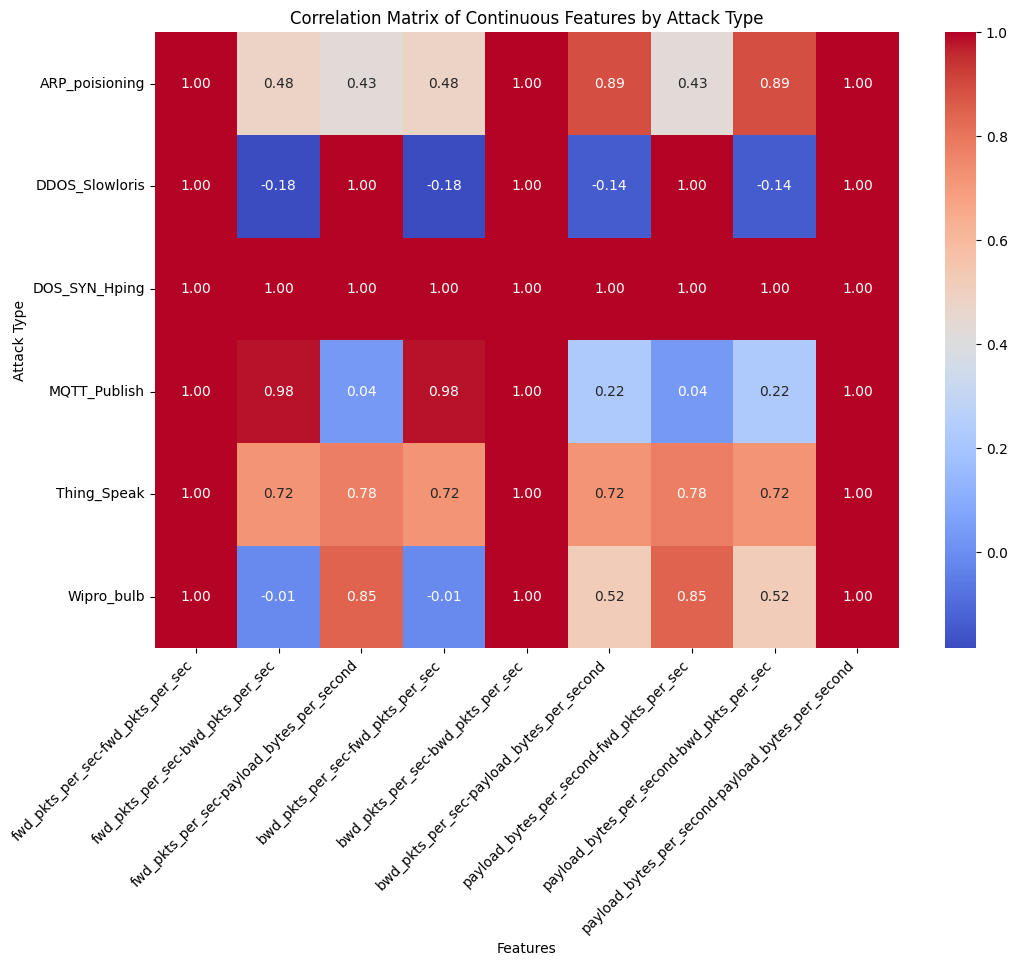

In [50]:
plt.figure(figsize=(12, 8))
sns.heatmap(atk_classes_rate_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Features by Attack Type')
plt.xlabel('Features')
plt.ylabel('Attack Type')
plt.xticks(rotation=45, ha='right')

plt.show()

### 5. How do time‑based features like fwd_iat.avg and bwd_iat.avg (mean inter‑arrival times) differ between various attack types and normal traffic?

In [43]:
time_features_atk_corr

fwd_iat.avg  bwd_iat.avg
Attack_type                                         
ARP_poisioning fwd_iat.avg     1.000000     0.840953
               bwd_iat.avg     0.840953     1.000000
DOS_SYN_Hping  fwd_iat.avg     0.000000     0.000000
               bwd_iat.avg     0.000000     0.000000
MQTT_Publish   fwd_iat.avg     1.000000     0.555960
               bwd_iat.avg     0.555960     1.000000
Others         fwd_iat.avg     1.000000     0.614811
               bwd_iat.avg     0.614811     1.000000
Thing_Speak    fwd_iat.avg     1.000000     0.077886
               bwd_iat.avg     0.077886     1.000000

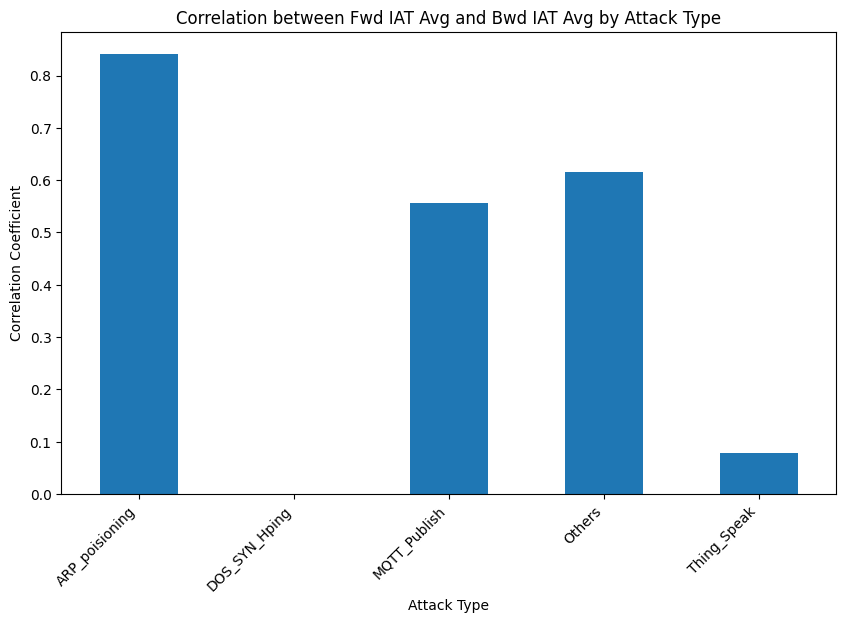

In [47]:
cross_correlation = time_features_atk_corr.loc[(slice(None), 'fwd_iat.avg'), 'bwd_iat.avg']
cross_correlation = cross_correlation.reset_index(level=1, drop=True)

plt.figure(figsize=(10, 6))
cross_correlation.plot(kind='bar')
plt.title('Correlation between Fwd IAT Avg and Bwd IAT Avg by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')


plt.show()

### 6. Which network flag counts (e.g., flow_SYN_flag_count, flow_RST_flag_count, fwd_PSH_flag_count) are most indicative of specific intrusion patterns?

In [30]:
atk_classes_flag_counts

,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count
Attack_type,,,
ARP_poisioning,7750,7750,7750
DDOS_Slowloris,534,534,534
DOS_SYN_Hping,50934,50934,50934
MQTT_Publish,4146,4146,4146
Thing_Speak,8108,8108,8108
Wipro_bulb,253,253,253


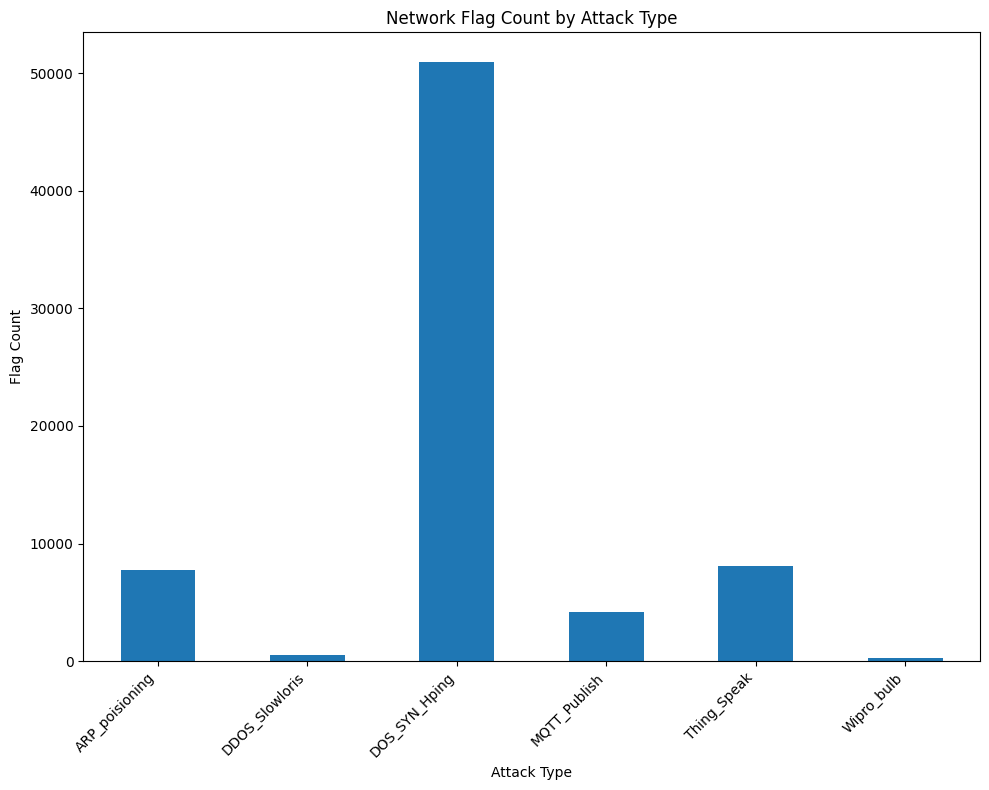

In [31]:
plt.figure(figsize=(10,8))
atk_classes_flag_counts['flow_SYN_flag_count'].plot(kind='bar')
plt.title("Network Flag Count by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Flag Count")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()